<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_OB_WEEK_06_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

딥러닝 파이토치 교과서 ch2. p.69~87

# Chapter 02. 실습환경 설정과 파이토치 기초

## 04. 파이토치 코드 맛보기



데이터셋 특성(칼럼)

1. price(지동차 가격)
2. maint(지동차 유지 비용)
3. doors(자동차 문 개수)
4. persons(수용 인원)
5. lug_capacity(수하물 용량)
6. safety(안전성)
7. output(차 상태): 이 데이터는 unacc(허용 불가능한 수준) 및 acc(허용 가능한 수준), 양호(good) 및 매우 좋은(very, good, vgood) 중 하나의 값을 갖음


In [1]:
import torch
import torch .nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
dataset = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/car.data', names=cols)
display(dataset.head())

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


출력 결과 다섯 개의 행이 단어와 숫자로 구성되어 있는 것을 확인할 수 있음

컴퓨터는 인간의 언어인 단어를 인식할 수 없기 때문에 단어를 벡터로 바꾸어 주는 임베딩(embedding) 처리가 필요

<Axes: ylabel='count'>

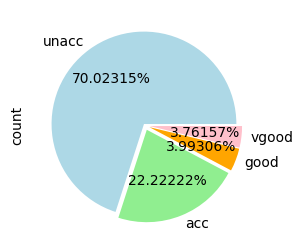

In [3]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 3
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie' , autopct='%0.05f%%',
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink' ], explode=(0.02, 0.05, 0.05, 0.05))

딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환해야 함

가장 먼저 필요한 전처리: 데이터 파악하는 것


In [4]:
categorical_columns = ['price', 'maint', 'doors', 'persons','lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category') # astype() 메서드를 이용하여 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors , persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

범주형 데이터를 댄서로 변환하기 위해 다음과 같은 절차가 필요

**범주형 데이터 -> dataset[category] -> 넘파이 배열(NumPy array) -> 텐서(Tensor)**

즉, 파이토치로 모델을 학습시키기 위해서는 텐서 형태로 변환해야 하는데, 넘파이 배열을 통해 텐서를 생성할 수 있음

넘파이 객체를 합칠 때 사용하는 메서드로는 np. stack과 np.concatenate가 있음

- np.stack: 배열들을 새로운 축으로 합쳐줌. 예를 들어 1차원 배열들을 합쳐서 2차원 배열을 만들거나 2차원 배열 여러 개를 합쳐 3차원 배열을 만듬. 따라서 반드시 두 배열의 차원이 동일해야 함

-  np.concatenate는 다음 그림과 같이 선택한 축(axis)을 기준으로 두 개의 배열을 연결함

In [5]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [6]:
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch. tensor(outputs).flatten()

print(categorical_data.shape)
print (outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


get_dummies: 가변수(dummy variable)로 만들어 주는 함수

-> 가변수로 만들어 준다는 의미: 문자를 숫자 (0, 1)로 바꾸어준다는 의미

워드 임베딩
- 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법

- 높은 차원의 임버딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있음

- 따라서 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용함


In [7]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in
                            categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in
                               categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [8]:
total_records = 1728
test_records = int (total_records * .2)
categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [9]:
print(len (categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [10]:
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni,
                                          nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    for i in layers:
      all_layers.append (nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True ))
      all_layers.append (nn.BatchNorm1d(i))
      all_layers.append (nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn. Sequential (*all_layers)

  def forward (self, x_categorical):
    embeddings = []
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))

    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

In [11]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50] , p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [12]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr=0.001)

In [13]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [14]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range (epochs):
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item() :10.8f}')

  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item() :10.10f}')

epoch:   1 loss: 1.49047935
epoch:  26 loss: 1.32015359
epoch:  51 loss: 1.22951043
epoch:  76 loss: 1.13674462
epoch: 101 loss: 1.01229048
epoch: 126 loss: 0.90008974
epoch: 151 loss: 0.82145369
epoch: 176 loss: 0.73249775
epoch: 201 loss: 0.68513989
epoch: 226 loss: 0.64432460
epoch: 251 loss: 0.62156188
epoch: 276 loss: 0.60945576
epoch: 301 loss: 0.58756733
epoch: 326 loss: 0.59382540
epoch: 351 loss: 0.59145474
epoch: 376 loss: 0.58285624
epoch: 401 loss: 0.57263541
epoch: 426 loss: 0.58284312
epoch: 451 loss: 0.56896150
epoch: 476 loss: 0.56783593
epoch: 500 loss: 0.5685205460


In [15]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.56974113


In [16]:
print(y_val[:5])

tensor([[ 4.0479,  3.2359, -5.2562, -4.2057],
        [ 2.5200,  1.4816, -3.3702, -3.2896],
        [ 2.1371,  1.2495, -2.8474, -2.6590],
        [ 1.9856,  1.0321, -2.3308, -2.4640],
        [ 1.6832,  0.8807, -2.4605, -2.4068]])


In [17]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[258   1]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7478260869565218


딥러닝 분류 모벨의 성능 평가 지표

성능 평가 지표로 정확도(accuracy), 재현율(recall), 정밀도(precision), F1-스코어(F1-score)가 있음

   - True Positive: 모델(분류기)이 '1'이라고 예측했는데 실제 값도 '1'인 경우
    - True Negative: 모델(분류기)이 '0'이라고 예측했는데 실제 값도 '0'인 경우
    - False Positive: 모델(분류기)이 '1'이라고 예측했는데 실제 값은 '0'인 경우로, Type1 오류라고도 함
    - False Negative: 모델(분류기)이 '0'이라고 예측했는데 실제 값은 '1'인 경우로，Type2 오류라고도 함



**정확도**
- 전체 예측 건수에서 정답을 맞힌 건수의 비율

-  이때 맞힌 정답이 긍정(positive)이든 부정(negative)이든 상관없음

    <img src="https://drive.google.com/uc?export=view&id=1xvWmpGh5KBrGQZtpFqM4j6f8HFSKewPn" width="550">



**재현율**
- 실제로 정답이 1이라고 할 때 모델(분류기)도 1로 예측한 비율

- 따라서 처음부터 데이터가 1일 획률이 적을 때 사용하면 좋음

    <img src="https://drive.google.com/uc?export=view&id=1NdqAwQRurw072ECYECkdT-VRgGzXM08z" width="300">



**정밀도**
- 모델(분류기)이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율

    <img src="https://drive.google.com/uc?export=view&id=1nQ5qEPjeB7NYaW6FdqlQ_O2l2cAWqmQS" width="300">


**F1-스코어**
- 일반적으로 정밀도와 재현율은 트레이드오프(trade-off) 관계

- 정밀도가 높으면 재현율이 낮고 재현율이 높으면 정밀도가 낮음

- 이러한 트레이드오프 문제를 해결하려고 정밀도와 재현율의 조화 평균(hannonic mean)을 이용한 것이 Fl-스코어 평가

- 조화 평균은 다음 공식으로 구할 수 있음

    <img src="https://drive.google.com/uc?export=view&id=1JLZ395BPGO4OTIxZoVc3gGYIdGzJUvLn" width="200">
